In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms 
from torchvision import datasets
from torch.utils.data import DataLoader , random_split
import matplotlib.pyplot as plt

In [7]:
device = torch.device('cpu')

In [8]:
transform = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.ToTensor()
])

In [9]:
dataset = datasets.ImageFolder(
    r'C:\Dl\PYTORCH_PROJECT_02\PetImages',
    transform=transform
)

In [10]:
dataset

Dataset ImageFolder
    Number of datapoints: 24998
    Root location: C:\Dl\PYTORCH_PROJECT_02\PetImages
    StandardTransform
Transform: Compose(
               Resize(size=(28, 28), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [11]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

In [12]:
print(train_size)
print(test_size)

19998
5000


In [13]:
train_data,test_data = random_split(
    dataset,
    [train_size,test_size]
)

In [14]:
len(train_data)

19998

In [15]:
len(test_data)

5000

In [16]:
train_loader = DataLoader(
    train_data,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=128,
    shuffle=False
)



In [17]:
len(train_loader)

157

In [18]:
len(test_loader)

40

In [19]:
class cat_dog(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=8,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=8,out_channels=16,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        
        self.Classifier = nn.Sequential(
            nn.Linear(16 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128,2)
        )
        
        
        
        
    def forward(self,x):
        x = self.features(x)
        x = x.view(x.size(0),-1)
        x = self.Classifier(x)
        return x
        
        
        
        
        
model = cat_dog().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

epochs = 4
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images,labels in train_loader:
        images = images.to(device)
        labels =labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = loss_fn(output,labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    print(f'Epoch No : {epoch+1}/{epochs} | Loss  : {total_loss}')
    
    
    
    
model.eval()
correct  = 0
total = 0
for images,labels in test_loader:
    images = images.to(device)
    labels =labels.to(device)
    output = model(images)
    prediction = output.argmax(dim=1)
    
    
    correct += (prediction == labels).sum().item()
    total += labels.size(0)
    
accuracy = correct/total *100
print(f'Accuracy : {accuracy}')
    

c:\Dl\deep_learning_venv\lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch No : 1/4 | Loss  : 104.23481047153473
Epoch No : 2/4 | Loss  : 93.60418859124184
Epoch No : 3/4 | Loss  : 88.62678229808807
Epoch No : 4/4 | Loss  : 85.42718249559402
Accuracy : 72.11999999999999


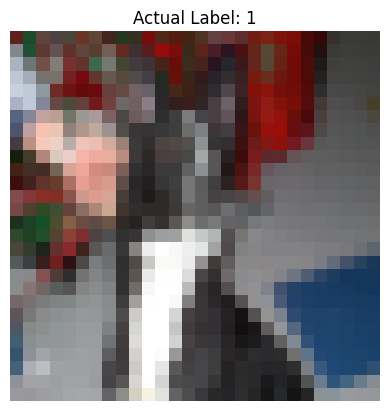

User Picked Index No: 4999
Actual Label: 1
Predicted Label: 1


In [20]:
index = 4999
image, true_label = test_data[index]

# Display RGB image
plt.imshow(image.permute(1, 2, 0))
plt.title(f'Actual Label: {true_label}')
plt.axis('off')
plt.show()

# Add batch dimension
# [3, 28, 28] → [1, 3, 28, 28]
image = image.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image)
    predicted_label = output.argmax(dim=1).item()

print(f'User Picked Index No: {index}')
print(f'Actual Label: {true_label}')
print(f'Predicted Label: {predicted_label}')

In [21]:
torch.save(model.state_dict(),'CAT_DOG_CLASSIFIER.pth')
print('Model is saved')

Model is saved
